In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

(training_images, training_labels), (testing_images, testing_labels) = datasets.cifar10.load_data()
training_images, testing_images = training_images/255, testing_images/255

class_names = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(training_images[i], cmap = plt.cm.binary)
    plt.xlabel(class_names[training_labels[i][0]])

#plt.show()

training_images = training_images[:20000]
training_labels = training_labels[:20000]
testing_images = testing_images[:4000]
testing_labels = testing_labels[:4000]

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(training_images, training_labels, epochs = 10, validation_data = (testing_images, testing_labels))

loss, accuracy = model.evaluate(testing_images, testing_labels)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

model.save('image_classifier.keras')



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Prediction is: Car


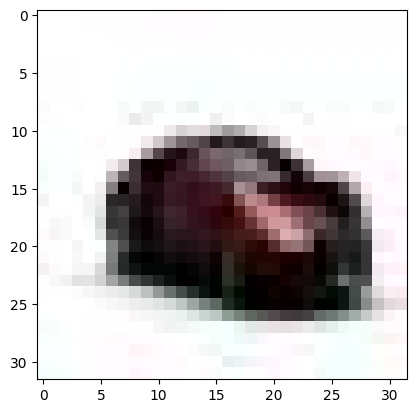

In [11]:
model = models.load_model('image_classifier.keras')

img = cv.imread('car.jpg')

if img is None:
    print("Error: Image not found. Please upload the image file to your Colab environment.")
else:
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    plt.imshow(img, cmap=plt.cm.binary)

    prediction = model.predict(np.array([img])/255)
    index = np.argmax(prediction)
    print(f"Prediction is: {class_names[index]}")

    plt.show()